# 01 - Data Preprocessing

Generates a grid of San Diego locations, computes environmental features for each,
and creates a composite safety score as the prediction target.

### Inputs
- `data/raw/crime_2023.csv` - SDPD calls for service
- `data/raw/walkability.csv` - EPA National Walkability Index
- `data/raw/census_bg/` - Census TIGER block group boundaries
- `data/raw/streetlights.geojson` - SD streetlight locations

### Output
- `data/processed/modeling_df.csv` - grid of SD locations with features + safety label

In [127]:
import pandas as pd
import geopandas as gpd
import numpy as np
from shapely.geometry import Point
from pathlib import Path
from tqdm import tqdm

RAW = Path('../data/raw')
PROCESSED = Path('../data/processed')
PROCESSED.mkdir(exist_ok=True)
print('Libraries loaded!')

Libraries loaded!


## 1. Generate San Diego Location Grid

In [128]:
LAT_MIN, LAT_MAX = 32.55, 33.10
LON_MIN, LON_MAX = -117.28, -116.93
LAT_STEP = 0.0045
LON_STEP = 0.0055

lats = np.arange(LAT_MIN, LAT_MAX, LAT_STEP)
lons = np.arange(LON_MIN, LON_MAX, LON_STEP)
grid_points = [(lat, lon) for lat in lats for lon in lons]
grid_df = pd.DataFrame(grid_points, columns=['lat', 'lon'])
grid_df['location_id'] = [f'sd_{i}' for i in range(len(grid_df))]

grid_gdf = gpd.GeoDataFrame(
    grid_df,
    geometry=gpd.points_from_xy(grid_df['lon'], grid_df['lat']),
    crs='EPSG:4326'
)
print(f'Grid points: {len(grid_gdf)}')
grid_gdf.head(3)

Grid points: 7872


,lat,lon,location_id,geometry
0,32.55,-117.2800,sd_0,POINT (-117.28 32.55)
1,32.55,-117.2745,sd_1,POINT (-117.2745 32.55)
2,32.55,-117.2690,sd_2,POINT (-117.269 32.55)


## 2. Load & Process Crime Data

In [129]:
# Load crime data
crime = pd.read_csv(RAW / 'crime_2024.csv', low_memory=False)
print('Crime shape:', crime.shape)

# Aggregate crime counts by beat
crime_by_beat = crime.groupby('BEAT').size().reset_index(name='crime_count')
crime_by_beat.columns = ['beat', 'crime_count']

# Normalize 0-1 and invert (higher = safer)
crime_by_beat['crime_density_norm'] = (
    crime_by_beat['crime_count'] - crime_by_beat['crime_count'].min()
) / (crime_by_beat['crime_count'].max() - crime_by_beat['crime_count'].min())
crime_by_beat['crime_score'] = 1 - crime_by_beat['crime_density_norm']

# Load beat boundaries and merge crime scores
beats_gdf = gpd.read_file(RAW / 'pd_beats_datasd.geojson').to_crs('EPSG:4326')
beats_with_crime = beats_gdf.merge(crime_by_beat, on='beat', how='left')
beats_with_crime['crime_score'] = beats_with_crime['crime_score'].fillna(
    beats_with_crime['crime_score'].median()
)

print('Beats with crime scores:', len(beats_with_crime))
print('Crime score variance:', beats_with_crime['crime_score'].var())
print(beats_with_crime[['beat', 'name', 'crime_count', 'crime_score']].dropna().head(10))

Crime shape: (970650, 14)
Beats with crime scores: 134
Crime score variance: 0.018722688981573907
    beat            name  crime_count  crime_score
0    935      NORTH CITY         2258     0.961859
1      0       SAN DIEGO            8     0.999966
3    722          NESTOR         6254     0.894181
4    314        BIRDLAND         5566     0.905833
5    839  CHEROKEE POINT         2976     0.949699
6    612     LOMA PORTAL         2482     0.958065
7    625        OLD TOWN         6234     0.894519
8    714          BORDER         3870     0.934557
9    832    TERALTA WEST         6482     0.890319
10   628         MIDTOWN         3902     0.934015


## 3. Load Walkability + Census Block Groups

In [130]:
walk = pd.read_csv(RAW / 'walkability.csv', low_memory=False)

walk_sd_fixed = walk[walk['COUNTYFP'] == 73].copy()
walk_sd_fixed['GEOID_fixed'] = (
    '06' +
    walk_sd_fixed['COUNTYFP'].astype(str).str.zfill(3) +
    walk_sd_fixed['TRACTCE'].astype(str).str.zfill(6) +
    walk_sd_fixed['BLKGRPCE'].astype(str).str.zfill(1)
)
walk_sd_fixed['walk_score'] = (
    walk_sd_fixed['NatWalkInd'] - walk_sd_fixed['NatWalkInd'].min()
) / (walk_sd_fixed['NatWalkInd'].max() - walk_sd_fixed['NatWalkInd'].min())

print(f'SD block groups: {len(walk_sd_fixed)}')
print(walk_sd_fixed[['GEOID_fixed', 'NatWalkInd', 'walk_score']].head(3))

SD block groups: 3443
       GEOID_fixed  NatWalkInd  walk_score
4633  060739505002    9.000000    0.428571
4634  060739506002    6.500000    0.294643
5333  060739508022    2.833333    0.098214


In [131]:
shp_files = list((RAW / 'census_bg').glob('*.shp'))
print('Shapefiles found:', shp_files)
census = gpd.read_file(shp_files[0])
census_sd = census[census['COUNTYFP'] == '073'].copy()
census_sd = census_sd.to_crs('EPSG:4326')
census_sd['GEOID'] = census_sd['GEOID'].astype(str)
census_walk = census_sd.merge(walk_sd_fixed, left_on='GEOID', right_on='GEOID_fixed', how='left')
print('Census+walk shape:', census_walk.shape)
print('Missing walk scores:', census_walk['walk_score'].isna().sum())

Shapefiles found: [PosixPath('../data/raw/census_bg/tl_2020_06_bg.shp')]
Census+walk shape: (2321, 132)
Missing walk scores: 558


## 4. Load Streetlights

In [132]:
import requests
import warnings
from shapely.geometry import shape
warnings.filterwarnings('ignore')

# Check if full streetlights already downloaded
full_path = RAW / 'streetlights_full.geojson'
if full_path.exists():
    lights = gpd.read_file(full_path)
    print(f'Loaded from cache: {lights.shape}')
else:
    # Paginate through ArcGIS REST API
    all_features = []
    offset = 0
    batch_size = 1000
    while True:
        url = (
            f"https://webmaps.sandiego.gov/arcgis/rest/services/Planning/PLN_Mobility/MapServer/1/query"
            f"?where=1%3D1&outFields=OBJECTID,STATUS,SHAPE&f=geojson"
            f"&resultOffset={offset}&resultRecordCount={batch_size}"
        )
        r = requests.get(url, verify=False)
        data = r.json()
        features = data.get('features', [])
        if not features:
            break
        all_features.extend(features)
        offset += batch_size
        print(f'Fetched {len(all_features)} so far...')
        if len(features) < batch_size:
            break

    geoms = [shape(f['geometry']) for f in all_features]
    lights = gpd.GeoDataFrame(
        [f['properties'] for f in all_features],
        geometry=geoms,
        crs='EPSG:4326'
    )
    lights.to_file(full_path, driver='GeoJSON')
    print(f'Fetched and saved: {lights.shape}')

lights = lights.to_crs('EPSG:4326')
print(f'Streetlights ready: {lights.shape}')

Loaded from cache: (56058, 3)
Streetlights ready: (56058, 3)


## 5. Spatial Join - Assign Walk Score to Grid Points

In [133]:
grid_walk = gpd.sjoin(
    grid_gdf,
    census_walk[['geometry', 'walk_score', 'NatWalkInd']],
    how='left',
    predicate='within'
)
grid_walk = grid_walk.drop_duplicates(subset='location_id')
print('After walk join:', grid_walk.shape)
print('Missing walk scores:', grid_walk['walk_score'].isna().sum())
grid_walk[['location_id', 'lat', 'lon', 'walk_score']].head(3)

After walk join: (7872, 7)
Missing walk scores: 2605


,location_id,lat,lon,walk_score
0,sd_0,32.55,-117.2800,NaN
1,sd_1,32.55,-117.2745,NaN
2,sd_2,32.55,-117.2690,NaN


In [135]:
# Reset index to remove index_right from previous sjoin
grid_walk = grid_walk.reset_index(drop=True)
if 'index_right' in grid_walk.columns:
    grid_walk = grid_walk.drop(columns=['index_right'])

# Spatially join beat crime scores to grid points
grid_walk = gpd.sjoin(
    grid_walk,
    beats_with_crime[['geometry', 'crime_score', 'crime_count']],
    how='left',
    predicate='within'
)
grid_walk = grid_walk.drop_duplicates(subset='location_id')
grid_walk['crime_score'] = grid_walk['crime_score'].fillna(
    grid_walk['crime_score'].median()
)

print('Crime score variance:', grid_walk['crime_score'].var())
print('Crime score range:', grid_walk['crime_score'].min(), '-', grid_walk['crime_score'].max())
print(grid_walk[['location_id', 'lat', 'lon', 'crime_score']].head(5))

Crime score variance: 0.007892736291839246
Crime score range: 0.0 - 0.9999661269561683
  location_id    lat       lon  crime_score
0        sd_0  32.55 -117.2800     0.894181
1        sd_1  32.55 -117.2745     0.894181
2        sd_2  32.55 -117.2690     0.894181
3        sd_3  32.55 -117.2635     0.894181
4        sd_4  32.55 -117.2580     0.894181


## 6. Compute Lighting Score (streetlights within 200m)

In [136]:
grid_proj = grid_walk.to_crs('EPSG:32611')
lights_proj = lights.to_crs('EPSG:32611')
lights_geom = lights_proj.geometry

light_counts = []
for geom in tqdm(grid_proj.geometry, desc='Computing light density'):
    buf = geom.buffer(200)
    light_counts.append(lights_geom.within(buf).sum())

grid_walk = grid_walk.copy()
grid_walk['light_count'] = light_counts
grid_walk['light_score'] = (
    grid_walk['light_count'] - grid_walk['light_count'].min()
) / (grid_walk['light_count'].max() - grid_walk['light_count'].min())
print('Light score stats:')
print(grid_walk['light_score'].describe())

Computing light density: 100%|██████████| 7872/7872 [00:11<00:00, 703.84it/s]

Light score stats:
count    7872.000000
mean        0.018995
std         0.052207
min         0.000000
25%         0.000000
50%         0.000000
75%         0.011111
max         1.000000
Name: light_score, dtype: float64


## 7. Assign Crime Score

In [137]:
# Crime score already assigned via spatial join above
print(f'Crime score variance: {grid_walk["crime_score"].var():.6f}')
print(f'Crime score range: {grid_walk["crime_score"].min():.3f} - {grid_walk["crime_score"].max():.3f}')
print(f'Unique crime scores: {grid_walk["crime_score"].nunique()}')

Crime score variance: 0.007893
Crime score range: 0.000 - 1.000
Unique crime scores: 120


## 8. Compute Composite Safety Score (Target Variable)

In [138]:
grid_walk['walk_score'] = grid_walk['walk_score'].fillna(grid_walk['walk_score'].median())

grid_walk['safety_score'] = (
    0.50 * grid_walk['crime_score'] +
    0.25 * grid_walk['walk_score'] +
    0.25 * grid_walk['light_score']
)

threshold = grid_walk['safety_score'].median()
grid_walk['safe_label'] = (grid_walk['safety_score'] >= threshold).astype(int)

print('Safety score stats:')
print(grid_walk['safety_score'].describe())
print('\nClass balance:')
print(grid_walk['safe_label'].value_counts())

Safety score stats:
count    7872.000000
mean        0.540736
std         0.063578
min         0.173859
25%         0.507358
50%         0.538608
75%         0.583251
max         0.761301
Name: safety_score, dtype: float64

Class balance:
safe_label
1    4696
0    3176
Name: count, dtype: int64


## 9. Save Modeling DataFrame

In [139]:
modeling_df = grid_walk[[
    'location_id', 'lat', 'lon',
    'crime_score', 'walk_score', 'NatWalkInd',
    'light_count', 'light_score',
    'safety_score', 'safe_label'
]].copy()
modeling_df = modeling_df.dropna(subset=['walk_score'])
modeling_df.to_csv(PROCESSED / 'modeling_df.csv', index=False)
print(f'Saved! Shape: {modeling_df.shape}')
modeling_df.describe()

Saved! Shape: (7872, 10)


,lat,lon,crime_score,walk_score,NatWalkInd,light_count,light_score,safety_score,safe_label
count,7872.000000,7872.000000,7872.000000,7872.000000,5267.000000,7872.000000,7872.000000,7872.000000,7872.000000
mean,32.824500,-117.106750,0.875762,0.392426,8.568603,3.419080,0.018995,0.540736,0.596545
std,0.159787,0.101608,0.088841,0.208865,4.747765,9.397275,0.052207,0.063578,0.490622
min,32.550000,-117.280000,0.000000,0.000000,1.000000,0.000000,0.000000,0.173859,0.000000
25%,32.685000,-117.193375,0.894181,0.303571,5.333333,0.000000,0.000000,0.507358,0.000000
50%,32.824500,-117.106750,0.894181,0.366071,7.833333,0.000000,0.000000,0.538608,1.000000
75%,32.964000,-117.020125,0.894181,0.526786,12.500000,2.000000,0.011111,0.583251,1.000000
max,33.099000,-116.933500,0.999966,1.000000,19.666667,180.000000,1.000000,0.761301,1.000000


## 10. EDA Plots

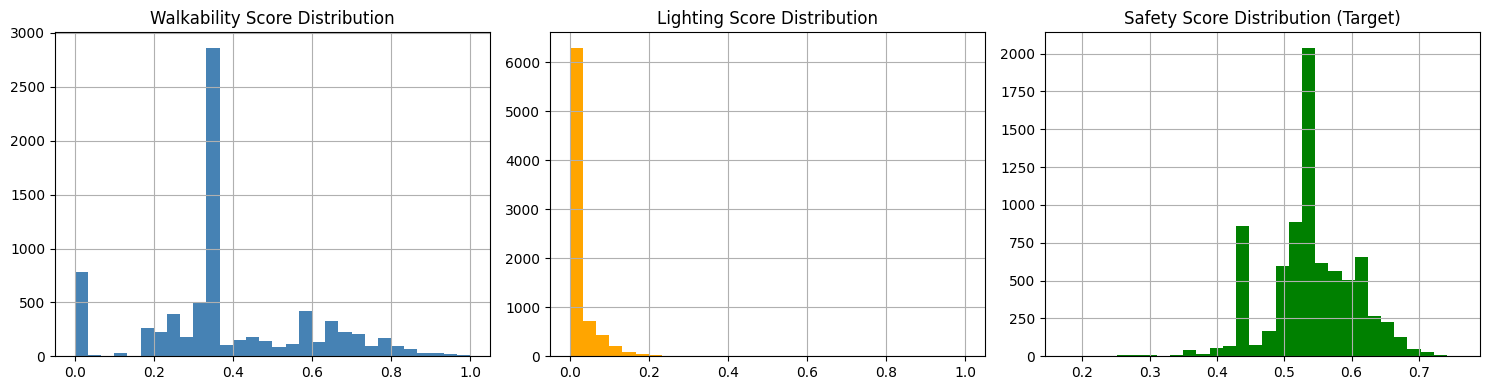

EDA plot saved!


In [140]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
modeling_df['walk_score'].hist(ax=axes[0], bins=30, color='steelblue')
axes[0].set_title('Walkability Score Distribution')
modeling_df['light_score'].hist(ax=axes[1], bins=30, color='orange')
axes[1].set_title('Lighting Score Distribution')
modeling_df['safety_score'].hist(ax=axes[2], bins=30, color='green')
axes[2].set_title('Safety Score Distribution (Target)')
plt.tight_layout()
plt.savefig(PROCESSED / 'eda_distributions.png', dpi=150)
plt.show()
print('EDA plot saved!')

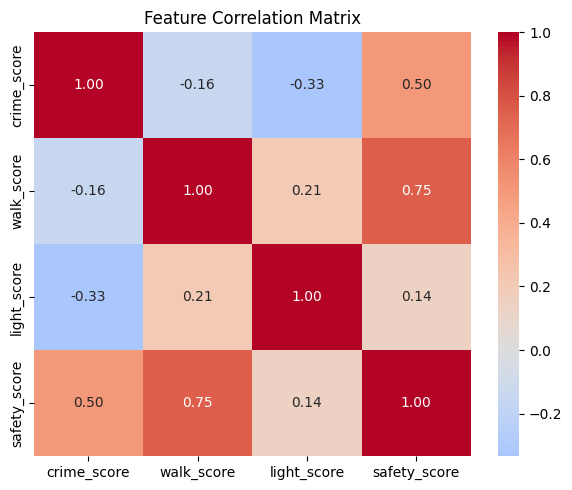

Correlation matrix saved!


In [141]:
corr_cols = ['crime_score', 'walk_score', 'light_score', 'safety_score']
corr = modeling_df[corr_cols].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig(PROCESSED / 'eda_correlation.png', dpi=150)
plt.show()
print('Correlation matrix saved!')